In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
import csv  
from matplotlib.colors import ListedColormap
from cartopy.feature import LAKES

C:\Users\x12la\AppData\Local\Temp\ipykernel_30820\2511498831.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


<h1> Load data

In [2]:
# EPA Idling data
oni_file = pd.read_csv('ONI_2022v1_projected_from_full_annual_20240226_monthly_18jun2024_nf_v5.csv',skiprows=14)
hotelling_file = pd.read_csv('HOTELING_2022v1_monthly_20240305_18jun2024_nf_v5.csv',skiprows=19)

cols = [
    "country_cd", "region_cd", "tribal_code", "census_tract_cd", "shape_id", "scc",
    "act_parm_type_cd", "act_parm_uofmsr", "activity_type", "ann_parm_value",
    "calc_year", "date_updated", "data_set_id",
    "jan_value", "feb_value", "mar_value", "apr_value", "may_value", "jun_value",
    "jul_value", "aug_value", "sep_value", "oct_value", "nov_value", "dec_value",
    "comment"
]

# Headers for epa files
oni_file.columns = cols
hotelling_file.columns = cols

In [3]:
hotelling_file.head()

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value,comment
0,US,1001,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,10301.760000,...,831.066014,919.798472,911.338842,970.593669,949.689081,951.890938,1013.760527,926.054299,840.010558,NaN
1,US,1003,NaN,NaN,NaN,2202620153,NaN,NaN,HOTELLING,469215.348710,...,37852.651346,41894.157985,41508.846318,44207.732182,43255.588666,43355.876878,46173.857574,42179.092760,38260.049449,NaN
2,US,1003,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,50979.051190,...,4112.594049,4551.693440,4509.830310,4803.057377,4699.609412,4710.505470,5016.671887,4582.650876,4156.856814,NaN
3,US,1009,NaN,NaN,NaN,2202620153,NaN,NaN,HOTELLING,70162.426173,...,5660.159803,6264.491933,6206.875741,6610.443912,6468.068563,6483.064799,6904.441387,6307.098627,5721.078610,NaN
4,US,1009,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,7622.968697,...,614.961930,680.621075,674.361222,718.207875,702.739157,704.368459,750.149951,685.250183,621.580603,NaN


In [4]:
oni_file.head()

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value,comment
0,US,1001,NaN,NaN,NaN,2201310192,NaN,NaN,IDLING,2.079052e+06,...,168223.422000,174243.938500,171343.053600,185595.464600,169345.852300,155740.442200,166094.887400,172394.538500,171330.566900,NaN
1,US,1001,NaN,NaN,NaN,2201320192,NaN,NaN,IDLING,8.878891e+04,...,7164.661449,7407.157204,7317.201632,7978.745642,7231.922950,6560.985155,6986.879388,7305.018075,7297.215823,NaN
2,US,1001,NaN,NaN,NaN,2201420192,NaN,NaN,IDLING,3.780918e+03,...,318.964910,328.928845,289.082343,299.322588,313.112720,341.819011,360.540571,340.195249,329.298519,NaN
3,US,1001,NaN,NaN,NaN,2201430192,NaN,NaN,IDLING,6.519475e+02,...,54.953155,56.705230,49.885497,51.665479,53.998978,58.924600,62.225415,58.660044,56.798038,NaN
4,US,1001,NaN,NaN,NaN,2201520192,NaN,NaN,IDLING,1.041123e+05,...,8690.204514,9480.567975,9335.224704,9674.370752,9339.968540,9170.288112,9379.870419,9278.172570,8924.765167,NaN


In [5]:
#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

In [ ]:
# 2021 census county boundary 
county = gpd.read_file('../US_county_2021.shp')
county = county.to_crs('EPSG:4326')

# formating edits to make merging with EPA data easier later on 
county_il =  county.loc[(county['STATEFP']=='17')]
county_il["STATEFP"] = county_il["STATEFP"].astype(str).str.zfill(2)
county_il["COUNTYFP"] = county_il["COUNTYFP"].astype(str).str.zfill(3)
county_il["region_cd"] = county_il["STATEFP"] + county_il["COUNTYFP"]

In [ ]:
# Upload LOCUS idling data for Illinois
# Column headers: grid_zone, MDT_avg_da, HDT_avg_da,Total_avg_,geometry
# MDT avg refers to Medium duty trucks and HDT Heavy Duty trucks

base = gpd.read_file('LOCUS_IL_Idling.shp')
base = base.to_crs('EPSG:4326')

base_cmap = gpd.clip(base, cmap_cty.to_crs('EPSG:4326'))  #clip to CMAP region

In [ ]:
# print 
base.head()

<h2> Calculate idling activitiy for each county

In [206]:
# make copies of projections
county_proj = county_il.to_crs(3857)
base_proj = base.to_crs(3857)

# grid area based on geom
base_proj["grid_area"] = base_proj.geometry.area

# find grid intersecting county boundaries
intersections = gpd.overlay(base_proj, county_proj, how="intersection")

# calc how much area is intersected with county 
# this is used to calculate area weighted of gridded idling hours
# to used a weighted area average to determine county idling totals 
# this is done by calc frac of area intersecting the county
# then multipliying the frac to the gridded today hours
intersections["intersect_area"] = intersections.geometry.area
intersections["frac"] = intersections["intersect_area"] / intersections["grid_area"]

for col in ["MDT_avg_da", "HDT_avg_da", "Total_avg_"]:
    intersections[f"{col}_weighted"] = intersections[col] * intersections["frac"]

# generate county totals (sum over all grid cells within and intersecting county boundary) 
county_activity = (
    intersections.groupby("GEOID")[[
        "MDT_avg_da_weighted", 
        "HDT_avg_da_weighted", 
        "Total_avg__weighted",
    ]]
    .sum()
    .reset_index()
)

# merge back to shapefile 
county_out = county_il.merge(county_activity, on="GEOID", how="left")

In [207]:
# save calc of county level idling hours per LOCUS data to new shapefile
# columns ending with _weighted refer to these calc values
#county_out.to_file('LOCUS_CountyIdling.shp')
county_out.head()

,GISJOIN,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry,region_cd,MDT_avg_da_weighted,HDT_avg_da_weighted,Total_avg__weighted
0,G1700010,17,001,00424202,17001,Adams,Adams County,06,H1,G4020,...,"41,754,318.000000",+39.9860525,-091.1949607,"192,703.487849","2,256,580,596.720000","POLYGON ((-90.91347 40.10446, -90.91349 40.101...",17001,"1,364.861723","1,380.336401","2,745.198124"
1,G1700030,17,003,00424203,17003,Alexander,Alexander County,06,H1,G4020,...,"44,639,203.000000",+37.1836583,-089.3495158,"179,289.542676","654,307,053.951000","POLYGON ((-89.17208 37.06831, -89.17295 37.067...",17003,70.527099,106.061015,176.588113
2,G1700050,17,005,00424204,17005,Bond,Bond County,06,H1,G4020,...,"6,462,629.000000",+38.8859240,-089.4365916,"130,909.294514","991,527,746.512000","POLYGON ((-89.25419 38.74202, -89.25419 38.741...",17005,350.334570,"1,000.228671","1,350.563241"
3,G1700070,17,007,00424205,17007,Boone,Boone County,06,H1,G4020,...,"3,360,626.000000",+42.3189831,-088.8242951,"114,620.240644","730,475,279.871000","POLYGON ((-88.70559 42.15354, -88.70568 42.153...",17007,546.850267,"2,208.866918","2,755.717185"
4,G1700090,17,009,00424206,17009,Brown,Brown County,06,H1,G4020,...,"4,144,346.000000",+39.9620694,-090.7503095,"133,596.865395","795,973,012.744000","POLYGON ((-90.51375 39.98789, -90.51316 39.986...",17009,201.816621,364.174053,565.990673


<h1> Visualize LOCUS Data at the County-Level

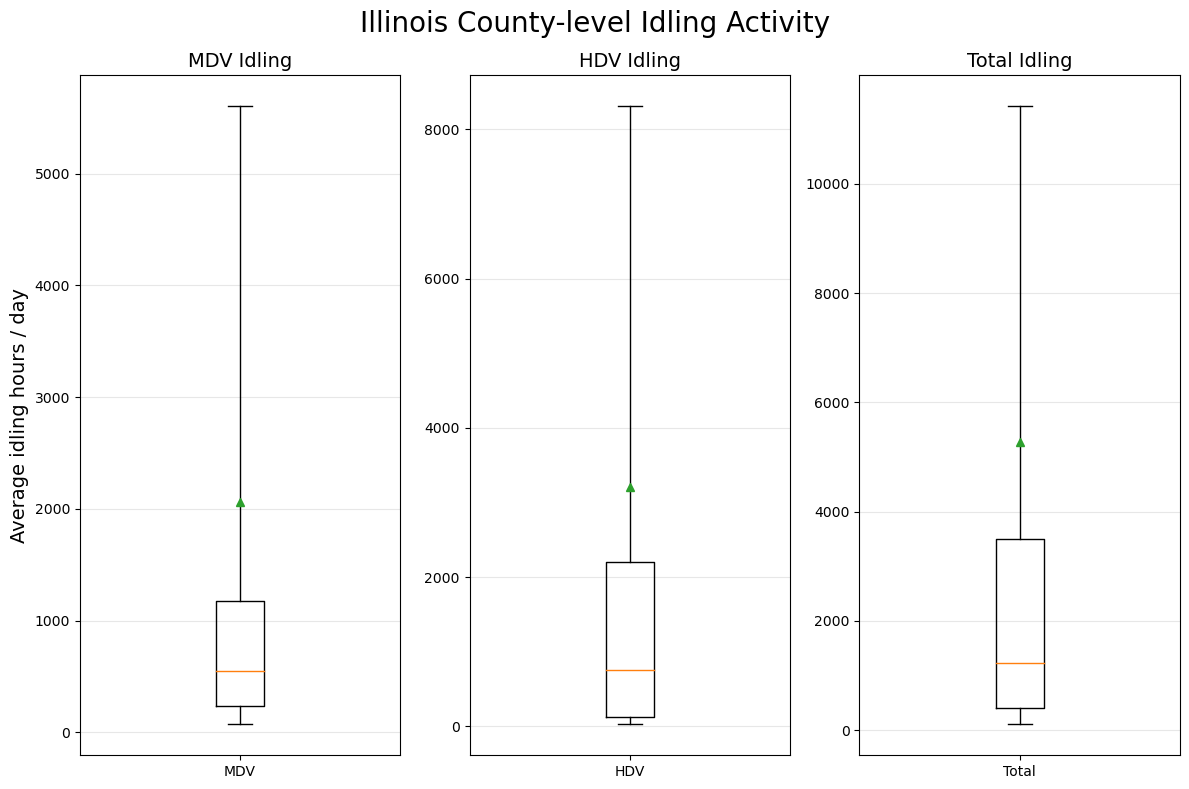

In [103]:
# set dicts
cols = ["MDT_avg_da_weighted", "HDT_avg_da_weighted", "Total_avg__weighted"]
dfp = county_out[cols].replace([np.inf, -np.inf], np.nan).dropna(how="any")
dfp = dfp.rename(columns={
    "MDT_avg_da_weighted": "MDV",
    "HDT_avg_da_weighted": "HDV",
    "Total_avg__weighted": "Total"
})

data_order = ["MDV", "HDV", "Total"]
data_arrays = {k: dfp[k].values for k in data_order}

# plot box & whisker
fig, axes = plt.subplots(1, 3, figsize=(12, 8)) 

for i, (ax, name) in enumerate(zip(axes, data_order)):
    ax.boxplot(
        [data_arrays[name]],
        labels=[name],
        whis=(5, 95), #whiskers are 5th and 95th percentiles
        showmeans=True,  # mean is a green triangle 
        showfliers=False,  # No outliers (they really skew the plots)
        notch=False 
    )
    ax.set_title(f"{name} Idling",fontsize=14)
    if i == 0:
        ax.set_ylabel("Average idling hours / day", fontsize=14)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=True) 
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Illinois County-level Idling Activity",fontsize=20)
fig.tight_layout()
plt.show()

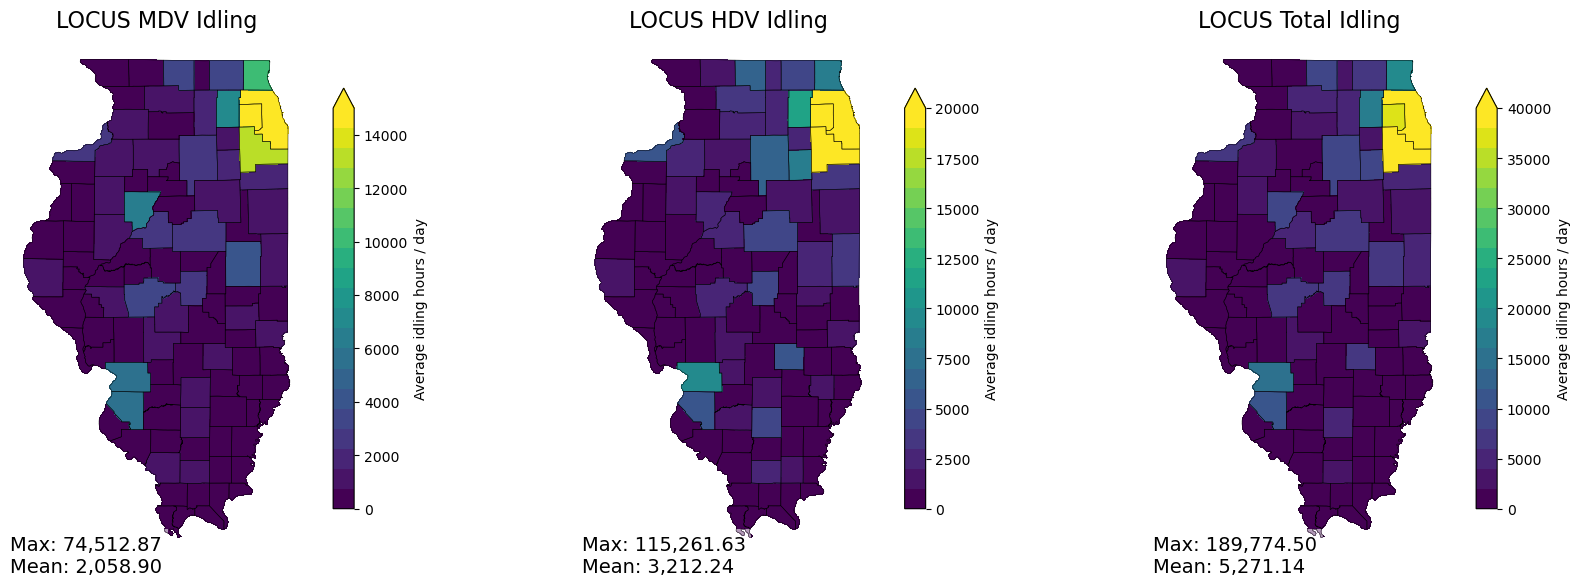

In [104]:
# discrete colorbar  -- can change colormap here as well if neccessary 
bwr_colors = plt.cm.viridis(np.linspace(0, 1, 20)) 
cmap_discrete = ListedColormap(bwr_colors)

# set dicts and y-axis extents 
panels = [("MDT_avg_da_weighted", "LOCUS MDV Idling"), ("HDT_avg_da_weighted", "LOCUS HDV Idling"), ("Total_avg__weighted", "LOCUS Total Idling")]
extents = {
    "MDT_avg_da_weighted": (0, 15000),   
    "HDT_avg_da_weighted": (0, 20000),   
    "Total_avg__weighted": (0, 40000),  
}


# Plot subplots of county-level idling todays from LOCUS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, title) in zip(axes, panels):
    vmin, vmax = extents[col]

    county_out.plot(
        column=col,
        ax=ax,
        cmap=cmap_discrete,
        vmin=vmin,
        vmax=vmax,
        legend=True,
        legend_kwds={"shrink": 0.8, "label": "Average idling hours / day","extend":'max'},
        antialiased=False,
    )
    ax.set_axis_off()
    ax.set_title(title, fontsize=16)
    county_out.boundary.plot(ax=ax, color="k", linewidth=0.4, zorder=10, alpha=0.8)
    vals = county_out[col].replace([np.inf, -np.inf], np.nan).dropna()
    mx = float(vals.max()) if not vals.empty else float("nan")
    mu = float(vals.mean()) if not vals.empty else float("nan")

    ax.text(
        0.0, 0.05,
        f"Max: {mx:,.2f}\nMean: {mu:,.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=14,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )
plt.tight_layout()
plt.show()


<h2> Calculate county-level idling from 2022v1 EPA files

In [105]:
# ONI For MDV
# First find where MDV row data is by finding sourceType 52 and 53 (Single unit long and short hauls)
# EPA data is provided in annual totals -- so I divide by 365 (days within 2022) to align it with LOCUS data 
mdv_oni = oni_file[oni_file["scc"].astype(str).str.zfill(10).str[4:6].isin(["52","53"])].copy()
mdv_oni["region_cd"] = mdv_oni["region_cd"].astype(str).str.zfill(5)  #fill just in case leading 0s are missing
mdv_oni["ann_parm_value"] = pd.to_numeric(mdv_oni["ann_parm_value"], errors="coerce")
mdv_per_day = mdv_oni.groupby("region_cd")["ann_parm_value"].sum() / 365.0 # annual est to daily
county_out["EPA_MDV_ONI"] = county_out["region_cd"].map(mdv_per_day).fillna(0)

# ONI for combination trucks 
# pull out sourceTypes for 61 and 62
# convert from annual to daily idling
scc_str_oni = oni_file["scc"].astype(str).str.zfill(10)
veh_code_oni = scc_str_oni.str[4:6] #veh code scc
proc_code_oni = scc_str_oni.str[8:10]  #process code 
hdv_oni = oni_file[(veh_code_oni.isin(["61","62"]))].copy() 
hdv_oni["region_cd"] = hdv_oni["region_cd"].astype(str).str.zfill(5)
hdv_oni["ann_parm_value"] = pd.to_numeric(hdv_oni["ann_parm_value"], errors="coerce")
hdv_oni_per_day = hdv_oni.groupby("region_cd")["ann_parm_value"].sum() / 365.0
county_out["EPA_HDV_ONI"] = county_out["region_cd"].map(hdv_oni_per_day).fillna(0)

# HDV hotelling 
# hotelling is only for SourceType 62 (long haul combination trucks)
# convert annual to daily 
scc_str_hot = hotelling_file["scc"].astype(str).str.zfill(10)
veh_code_hot = scc_str_hot.str[4:6] #veh code scc
proc_code_hot = scc_str_hot.str[8:10] #process code 
hdv_hot = hotelling_file[(veh_code_hot == "62")].copy() 
hdv_hot["region_cd"] = hdv_hot["region_cd"].astype(str).str.zfill(5)
hdv_hot["ann_parm_value"] = pd.to_numeric(hdv_hot["ann_parm_value"], errors="coerce")
hdv_hot_per_day = hdv_hot.groupby("region_cd")["ann_parm_value"].sum() / 365.0
county_out["EPA_HDV_HOTELING"] = county_out["region_cd"].map(hdv_hot_per_day).fillna(0)

# Calc Totals for MDV and HDV for overall comparisons 
county_out["EPA_HDV_Total"] = county_out["EPA_HDV_ONI"] + county_out["EPA_HDV_HOTELING"]
county_out["EPA_Total"] = county_out["EPA_MDV_ONI"] + county_out["EPA_HDV_Total"]

<h3> Visualize EPA Idling Data

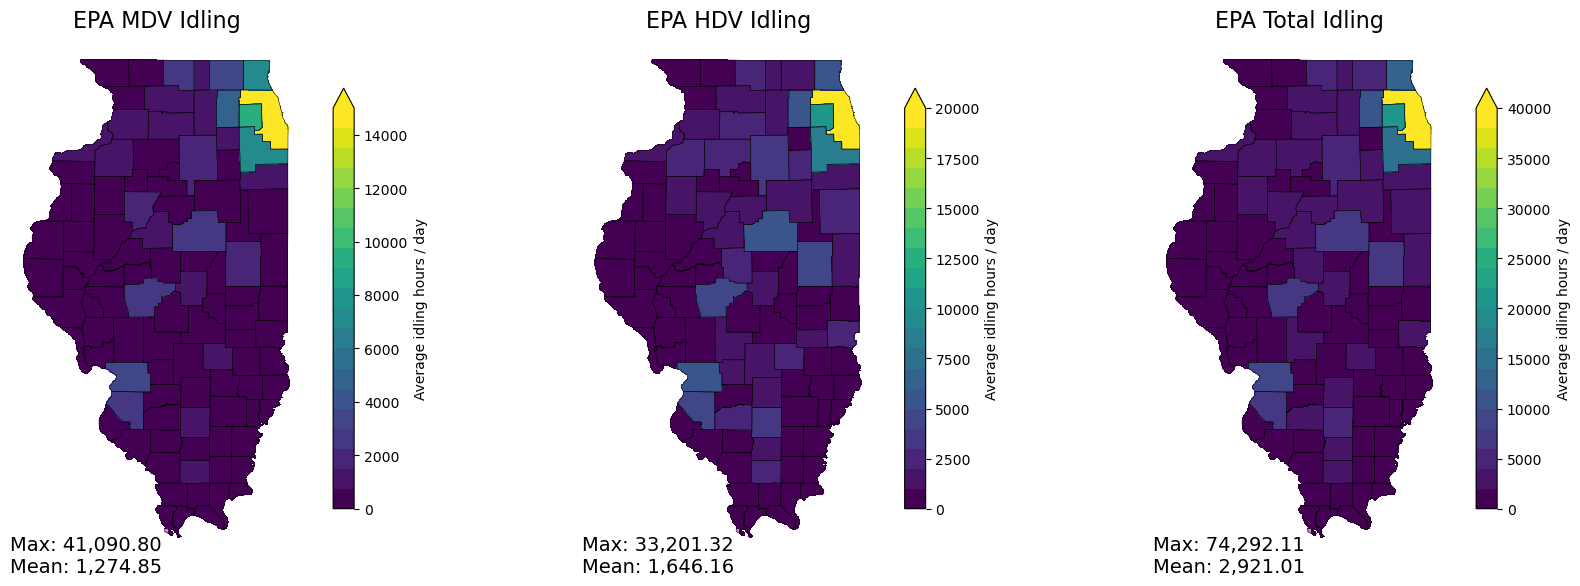

In [106]:
bwr_colors = plt.cm.viridis(np.linspace(0, 1, 20)) 
cmap_discrete = ListedColormap(bwr_colors)

panels = [("EPA_MDV_ONI", "EPA MDV Idling"), ("EPA_HDV_Total", "EPA HDV Idling"), ("EPA_Total", "EPA Total Idling")]
extents = {
    "EPA_MDV_ONI": (0, 15000),    
    "EPA_HDV_Total": (0, 20000),   
    "EPA_Total": (0, 40000),   
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, title) in zip(axes, panels):
    vmin, vmax = extents[col]
    
    county_out.plot(
        column=col,
        ax=ax,
        cmap=cmap_discrete,
        vmin=vmin,
        vmax=vmax,
        legend=True,
        legend_kwds={"shrink": 0.8, "label": "Average idling hours / day","extend":'max'},
        antialiased=False,
    )
    ax.set_axis_off()
    ax.set_title(title, fontsize=16)
    county_out.boundary.plot(ax=ax, color="k", linewidth=0.4, zorder=10, alpha=0.8)
    vals = county_out[col].replace([np.inf, -np.inf], np.nan).dropna()
    mx = float(vals.max()) if not vals.empty else float("nan")
    mu = float(vals.mean()) if not vals.empty else float("nan")

    ax.text(
        0.0, 0.05,
        f"Max: {mx:,.2f}\nMean: {mu:,.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=14,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

plt.tight_layout()
plt.show()

<h2> Calculate difference between EPA and LOCUS data (LOCUS - EPA)

In [200]:
print(county_out["MDT_avg_da_weighted"].sum())
print(county_out["EPA_MDV_ONI"].sum())

210007.78279478356
130034.53813968663


In [203]:
print(county_out["HDT_avg_da_weighted"].sum())
print(county_out["EPA_HDV_Total"].sum())

327648.1589417449
167908.20584480208


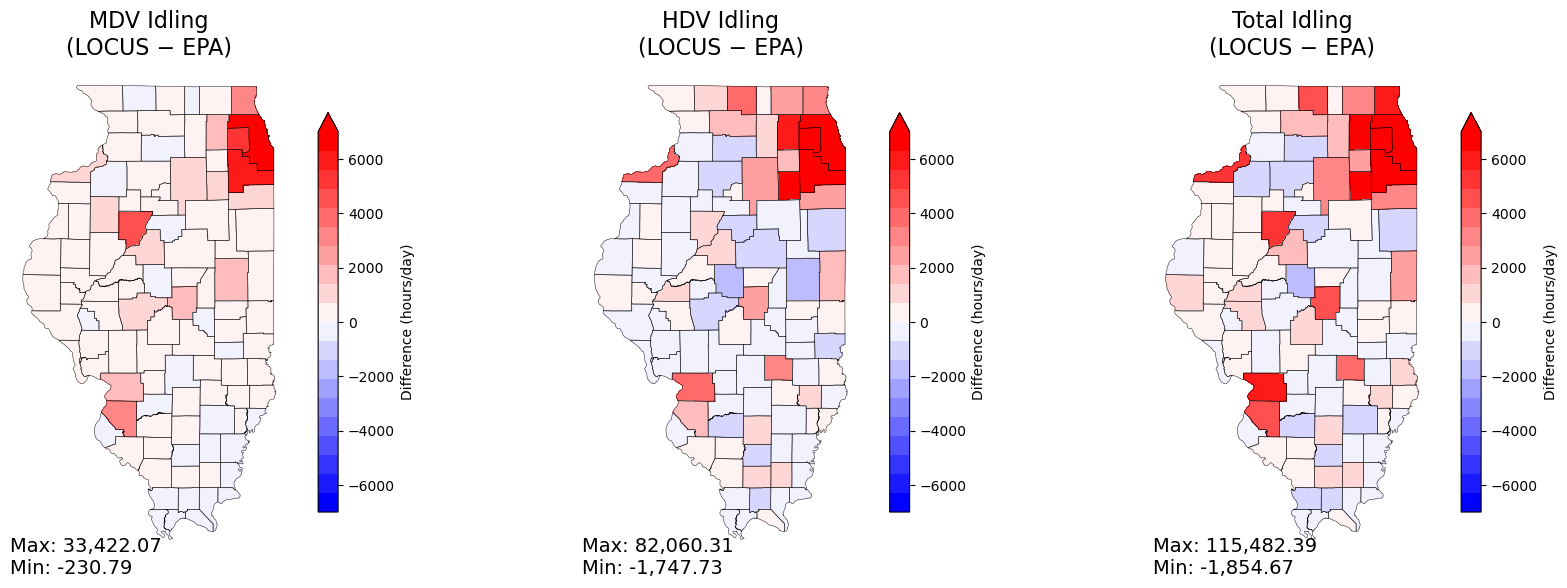

In [107]:
# calc diffs (LOCUS-EPA)
county_out["DIFF_MDV"] = county_out["MDT_avg_da_weighted"]   - county_out["EPA_MDV_ONI"]
county_out["DIFF_HDV"] = county_out["HDT_avg_da_weighted"]   - county_out["EPA_HDV_Total"]
county_out["DIFF_TOT"] = county_out["Total_avg__weighted"]   - county_out["EPA_Total"]

# set dicts
panels = [
    ("DIFF_MDV", "MDV Idling\n(LOCUS − EPA)"),
    ("DIFF_HDV", "HDV Idling\n(LOCUS − EPA)"),
    ("DIFF_TOT", "Total Idling\n(LOCUS − EPA)"),
]

# discrete colormap 
bwr_colors = plt.cm.bwr(np.linspace(0, 1, 20)) 
cmap_discrete = ListedColormap(bwr_colors)

#plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, title) in zip(axes, panels):

    county_out.plot(
        column=col,
        ax=ax,
        cmap=cmap_discrete,         
        vmin=-7000, vmax=7000,   ## may be useful to mod this to have unique y-axis for each figure...
        legend=True,
        legend_kwds={"shrink": 0.8, "label": "Difference (hours/day)","extend":"max"},
        antialiased=False,
    )
    ax.set_axis_off()
    ax.set_title(title, fontsize=16)
    county_out.boundary.plot(ax=ax, color="k", linewidth=0.4, zorder=10, alpha=0.8)
    vals = county_out[col].replace([np.inf, -np.inf], np.nan).dropna()
    # calc max/min diffs and annotate sub figs
    mn = float(vals.min()) if not vals.empty else float("nan")
    mx = float(vals.max()) if not vals.empty else float("nan")
    ax.text(
        0.0, 0.05,
        f"Max: {mx:,.2f}\nMin: {mn:,.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=14,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

plt.tight_layout()
plt.show()

<h2> Modify EPA Files to reflect idling data from LOCUS observations

In [176]:
# EPA Idling data 
oni_file = pd.read_csv('ONI_2022v1_projected_from_full_annual_20240226_monthly_18jun2024_nf_v5.csv',skiprows=14)
hotelling_file = pd.read_csv('HOTELING_2022v1_monthly_20240305_18jun2024_nf_v5.csv',skiprows=19)

cols = [
    "country_cd", "region_cd", "tribal_code", "census_tract_cd", "shape_id", "scc",
    "act_parm_type_cd", "act_parm_uofmsr", "activity_type", "ann_parm_value",
    "calc_year", "date_updated", "data_set_id",
    "jan_value", "feb_value", "mar_value", "apr_value", "may_value", "jun_value",
    "jul_value", "aug_value", "sep_value", "oct_value", "nov_value", "dec_value",
    "comment"
]

# headers for epa files
oni_file.columns = cols
hotelling_file.columns = cols

oni_file["region_cd"]    = oni_file["region_cd"].astype(str).str.zfill(5)
hotelling_file["region_cd"] = hotelling_file["region_cd"].astype(str).str.zfill(5)
scc_oni = oni_file["scc"].astype(str).str.zfill(10)
oni_file["veh_code"]  = scc_oni.str[4:6]
scc_hot = hotelling_file["scc"].astype(str).str.zfill(10)
hotelling_file["veh_code"]  = scc_hot.str[4:6]


In [177]:
# Calc monthly ratios so that we can transpose them later on..
month_cols = [
    "jan_value","feb_value","mar_value","apr_value","may_value","jun_value",
    "jul_value","aug_value","sep_value","oct_value","nov_value","dec_value"
]
ratio_cols = [c.replace("_value","_ratio") for c in month_cols]

for df in (oni_file, hotelling_file):
    df[month_cols] = df[month_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    df["ann_parm_value"] = pd.to_numeric(df["ann_parm_value"], errors="coerce").fillna(0.0)

for df in (oni_file, hotelling_file):
    denom = df["ann_parm_value"].replace(0, np.nan)
    for m in month_cols:
        df[m.replace("_value", "_ratio")] = (df[m] / denom).fillna(0.0)

In [178]:
# format data for calcs
oni_file["region_cd"]   = oni_file["region_cd"].astype(str).str.zfill(5)
scc_str = oni_file["scc"].astype(str).str.zfill(10)
oni_file["veh_code"]  = scc_str.str[4:6] 
pd.set_option("display.float_format", "{:,.6f}".format)

In [179]:
# A few print statements for QA checks down the road
oni_file.loc[(oni_file['region_cd']=='17031') & (oni_file["veh_code"].isin(["52","53","61","62"])) ]

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,mar_ratio,apr_ratio,may_ratio,jun_ratio,jul_ratio,aug_ratio,sep_ratio,oct_ratio,nov_ratio,dec_ratio
11858,US,17031,NaN,NaN,NaN,2201520192,NaN,NaN,IDLING,"5,263,398.530000",...,0.087989,0.084330,0.087921,0.087870,0.086954,0.088734,0.083434,0.088967,0.079182,0.077220
11859,US,17031,NaN,NaN,NaN,2201530192,NaN,NaN,IDLING,"275,409.436300",...,0.087992,0.084323,0.087919,0.087872,0.086953,0.088733,0.083431,0.088970,0.079185,0.077217
11860,US,17031,NaN,NaN,NaN,2201610192,NaN,NaN,IDLING,"4,243.243977",...,0.088021,0.085634,0.087519,0.088470,0.084635,0.088145,0.083872,0.087436,0.079377,0.075085
11868,US,17031,NaN,NaN,NaN,2202520192,NaN,NaN,IDLING,"8,632,081.771000",...,0.087989,0.084330,0.087921,0.087870,0.086954,0.088734,0.083434,0.088967,0.079182,0.077220
11869,US,17031,NaN,NaN,NaN,2202530192,NaN,NaN,IDLING,"687,557.819200",...,0.087992,0.084323,0.087919,0.087872,0.086953,0.088733,0.083431,0.088970,0.079185,0.077217
11870,US,17031,NaN,NaN,NaN,2202610192,NaN,NaN,IDLING,"4,871,835.012000",...,0.088021,0.085634,0.087519,0.088470,0.084635,0.088145,0.083872,0.087436,0.079377,0.075085
11871,US,17031,NaN,NaN,NaN,2202620192,NaN,NaN,IDLING,"3,311,731.344000",...,0.087159,0.086242,0.086974,0.087079,0.083827,0.088684,0.082185,0.090296,0.083080,0.073850
11874,US,17031,NaN,NaN,NaN,2203520192,NaN,NaN,IDLING,"133,976.576900",...,0.087989,0.084330,0.087921,0.087870,0.086954,0.088734,0.083434,0.088967,0.079182,0.077220
11875,US,17031,NaN,NaN,NaN,2203530192,NaN,NaN,IDLING,"5,716.935015",...,0.087992,0.084323,0.087919,0.087872,0.086953,0.088733,0.083431,0.088970,0.079185,0.077217
11876,US,17031,NaN,NaN,NaN,2203610192,NaN,NaN,IDLING,"49,991.035370",...,0.088021,0.085634,0.087519,0.088470,0.084635,0.088145,0.083872,0.087436,0.079377,0.075085


In [180]:
# A few print statements for QA checks down the road
hotelling_file.loc[(hotelling_file['region_cd']=='17031') & (hotelling_file["veh_code"].isin(["52","53","61","62"])) ]

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,mar_ratio,apr_ratio,may_ratio,jun_ratio,jul_ratio,aug_ratio,sep_ratio,oct_ratio,nov_ratio,dec_ratio
469,US,17031,NaN,NaN,NaN,2202620153,NaN,NaN,HOTELLING,"3,500,373.360000",...,0.087127,0.086217,0.086941,0.087149,0.083849,0.088669,0.082181,0.090221,0.082809,0.073965
470,US,17031,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,"380,306.640000",...,0.087127,0.086217,0.086941,0.087149,0.083849,0.088669,0.082181,0.090221,0.082809,0.073965


In [181]:
print('total hoteling from HDVs')
(3500373.360000+380306.640000)

total hoteling from HDVs


3880680.0

In [182]:
# Sanity print outs to manually check calculations 
print(oni_file.loc[(oni_file['region_cd']=='17031') & (oni_file["veh_code"].isin(["52","53"]))]['jan_ratio'])
print(oni_file.loc[(oni_file['region_cd']=='17031') & (oni_file["veh_code"].isin(["52","53"]))]['jan_value'])

11858   0.074984
11859   0.074983
11868   0.074984
11869   0.074983
11874   0.074984
11875   0.074983
Name: jan_ratio, dtype: float64
11858   394,668.848800
11859    20,651.126860
11868   647,265.023800
11869    51,555.400370
11874    10,046.053150
11875       428.675037
Name: jan_value, dtype: float64


In [185]:
# Sanity print outs to manually check calculations 
print(hotelling_file.loc[(hotelling_file['region_cd']=='17031') & (hotelling_file["veh_code"].isin(["62"]))]['jan_ratio'])
print(hotelling_file.loc[(hotelling_file['region_cd']=='17031') & (hotelling_file["veh_code"].isin(["62"]))]['jan_value'])

469   0.081612
470   0.081612
Name: jan_ratio, dtype: float64
469   285,671.007500
470    31,037.426536
Name: jan_value, dtype: float64


<h3> MDV ONI 

In [186]:
# Make mask 
# Rewriting some from code above to keep my logic organized without scrolling (: 
oni_file["region_cd"]   = oni_file["region_cd"].astype(str).str.zfill(5)
county_out["region_cd"] = county_out["region_cd"].astype(str).str.zfill(5)
scc_str = oni_file["scc"].astype(str).str.zfill(10)
oni_file["veh_code"]  = scc_str.str[4:6]  
oni_file["fuel_code"] = scc_str.str[2:4]  # this is fuel types 
mdv_oni = oni_file[oni_file["veh_code"].isin(["52","53"])].copy()
mdv_oni["ann_parm_value"] = pd.to_numeric(mdv_oni["ann_parm_value"], errors="coerce").fillna(0.0)

# locus data mapped to oni file using county code (region_cd) as index 
county_out["LOCUS_MDV_ann"] = county_out["MDT_avg_da_weighted"] * 365  #This data is for 2024, which is a leap year but im mapping it to the 2022 inventory, so 365 is fine
locus_mdv_ann = county_out.set_index("region_cd")["LOCUS_MDV_ann"] 
mdv_oni["LOCUS_MDV_ann"] = mdv_oni["region_cd"].map(locus_mdv_ann).fillna(0.0)

# logic here:
# Determine MDV ONI (52/53) total per count (den_total).
# Next, calculate of the total, per county, how much idling was distributed across vehicle code 52/53 and fuel types. 
# Then,take LOCUS county-level totals for MDV and update ann_parm_value for EPA Idling
# based on the ratios of current activity. Therefore, the general characterization is not
# modified, but total idling activity is increased proportionately. 
mdv_oni["den_total"] = mdv_oni.groupby("region_cd")["ann_parm_value"].transform("sum") #total ONI by 52/53 at county (region_cd) level
mdv_oni["weight"] = 0.0 # initialize 
nz = mdv_oni["den_total"] > 0 # Make sure is nonzero
mdv_oni.loc[nz, "weight"] = mdv_oni.loc[nz, "ann_parm_value"] / mdv_oni.loc[nz, "den_total"] #calc ratio of sinlge unit fuel type combo to total idling
if (~nz).any():
    n_rows = mdv_oni.loc[~nz].groupby("region_cd")["region_cd"].transform("count")
    mdv_oni.loc[~nz, "weight"] = 1.0 / n_rows  # equal split only when ONI has zero total

mdv_oni["LOCUS_alloc_MDV_ann"] = mdv_oni["LOCUS_MDV_ann"] * mdv_oni["weight"]  # LOCUS data allocated to EPA defs based on weights we determined above
mdv_oni["LOCUS_alloc_MDV_da"]  = mdv_oni["LOCUS_alloc_MDV_ann"] / 365.0

oni_file["LOCUS_alloc_MDV_da"] = 0.0
oni_file.loc[mdv_oni.index, "LOCUS_alloc_MDV_ann"] = mdv_oni["LOCUS_alloc_MDV_ann"].astype(float).fillna(0.0).values
oni_file.loc[mdv_oni.index, "LOCUS_alloc_MDV_da"]  = mdv_oni["LOCUS_alloc_MDV_da"].astype(float).fillna(0.0).values

In [187]:
#Convert locus daily to annual idling
county_out["LOCUS_HDV_ann"] = county_out["HDT_avg_da_weighted"] * 365.0
loc_hdv_ann = county_out.set_index("region_cd")["LOCUS_HDV_ann"]

# HDV here will defined as combination trucks (scc 61 or 62)
hdv_oni = oni_file[oni_file["veh_code"].isin(["61","62"])].copy()
hdv_hot = hotelling_file[hotelling_file["veh_code"].isin(["61","62"])].copy()  # typically 62 only but just to safe 

# Make EPA values numeric
for df in (hdv_oni, hdv_hot):
    df["ann_parm_value"] = pd.to_numeric(df["ann_parm_value"], errors="coerce").fillna(0.0)

# Keep a reference to original row indices for future ref
hdv_oni["row_index"] = hdv_oni.index
hdv_hot["row_index"] = hdv_hot.index

# Build a single comparison table with source flag bc HDV idling comes from both ONI and hotelling 
epa_hdv_oni = hdv_oni[["region_cd","ann_parm_value","row_index"]].copy()
epa_hdv_oni["source"] = "ONI"
epa_hdv_hot = hdv_hot[["region_cd","ann_parm_value","row_index"]].copy()
epa_hdv_hot["source"] = "HOT"
epa_hdv = pd.concat([epa_hdv_oni, epa_hdv_hot], ignore_index=True)

# logic here:  Determine MDV ONI (52/53) total per count (den_total). 
# Next, calculate of the total, per county, how much idling was distributed across vehicle code 52/53 and fuel types. 
# Then,take LOCUS county-level totals for MDV and update ann_parm_value for EPA Idling 
# based on the ratios of current activity. Therefore, the general characterization is not 
# modified, but total idling activity is increased proportionately.
epa_hdv["den_total"] = epa_hdv.groupby("region_cd")["ann_parm_value"].transform("sum")
epa_hdv["weight"] = 0.0
nz = epa_hdv["den_total"] > 0
epa_hdv.loc[nz, "weight"] = epa_hdv.loc[nz, "ann_parm_value"] / epa_hdv.loc[nz, "den_total"]
# if (~nz).any():
#     n_rows = epa_hdv.loc[~nz].groupby("region_cd")["region_cd"].transform("count")
#     epa_hdv.loc[~nz, "weight"] = 1.0 / n_rows  # equal split only when ONI has zero total

# Take the weight and scale LOCUS data accordingly 
epa_hdv["LOCUS_HDV_ann"]       = epa_hdv["region_cd"].map(loc_hdv_ann).fillna(0.0)
epa_hdv["LOCUS_alloc_HDV_ann"] = epa_hdv["LOCUS_HDV_ann"] * epa_hdv["weight"]
epa_hdv["LOCUS_alloc_HDV_da"]  = epa_hdv["LOCUS_alloc_HDV_ann"] / 365.0

# Add to original tables 
# Ensure destination columns exist
for df in (oni_file, hotelling_file):
    if "LOCUS_alloc_HDV_ann" not in df.columns: df["LOCUS_alloc_HDV_ann"] = 0.0
    if "LOCUS_alloc_HDV_da"  not in df.columns: df["LOCUS_alloc_HDV_da"]  = 0.0

sel_oni = epa_hdv[epa_hdv["source"]=="ONI"]
oni_file.loc[sel_oni["row_index"], "LOCUS_alloc_HDV_ann"] = sel_oni["LOCUS_alloc_HDV_ann"].values
oni_file.loc[sel_oni["row_index"], "LOCUS_alloc_HDV_da"]  = sel_oni["LOCUS_alloc_HDV_da"].values

sel_hot = epa_hdv[epa_hdv["source"]=="HOT"]
hotelling_file.loc[sel_hot["row_index"], "LOCUS_alloc_HDV_ann"] = sel_hot["LOCUS_alloc_HDV_ann"].values
hotelling_file.loc[sel_hot["row_index"], "LOCUS_alloc_HDV_da"]  = sel_hot["LOCUS_alloc_HDV_da"].values

In [188]:
# checking my work for Cook county... 
rc = "17031"
chk = (mdv_oni.loc[mdv_oni["region_cd"] == rc, ["veh_code","fuel_code","ann_parm_value","weight","LOCUS_alloc_MDV_da"]]
              .sort_values(["veh_code","fuel_code"]))
print("\n[MDV 17031] ONI veh/fuel annual totals & weights:")
print(chk.groupby(["veh_code","fuel_code"], as_index=False)["ann_parm_value"].sum()
         .assign(share=lambda d: d["ann_parm_value"] / d["ann_parm_value"].sum())
         .to_string(index=False))


[MDV 17031] ONI veh/fuel annual totals & weights:
veh_code fuel_code   ann_parm_value    share
      52        01 5,263,398.530000 0.350937
      52        02 8,632,081.771000 0.575543
      52        03   133,976.576900 0.008933
      53        01   275,409.436300 0.018363
      53        02   687,557.819200 0.045843
      53        03     5,716.935015 0.000381


In [189]:
# Sanity print outs to manually check calculations 
print(oni_file.loc[(oni_file['region_cd']=='17031') & (oni_file["veh_code"].isin(["52","53"]))]['jan_ratio'])
print(oni_file.loc[(oni_file['region_cd']=='17031') & (oni_file["veh_code"].isin(["52","53"]))]['jan_value'])

11858   0.074984
11859   0.074983
11868   0.074984
11869   0.074983
11874   0.074984
11875   0.074983
Name: jan_ratio, dtype: float64
11858   394,668.848800
11859    20,651.126860
11868   647,265.023800
11869    51,555.400370
11874    10,046.053150
11875       428.675037
Name: jan_value, dtype: float64


In [190]:
# checking my work for Cook county... 
# total HDV idling 
rc = "17031"
chk = (sel_hot.loc[sel_hot["region_cd"] == rc, ["ann_parm_value","weight","LOCUS_alloc_HDV_da"]])
print("\n[HDV 17031] veh/fuel annual totals & weights:")
print(chk)


[HDV 17031] veh/fuel annual totals & weights:
        ann_parm_value   weight  LOCUS_alloc_HDV_da
12040 3,500,373.360000 0.288846       33,292.848638
12041   380,306.640000 0.031382        3,617.183111


<h3> HDV ONI + Hotelling 

In [191]:
# Double checking with manual print outs for Cook county (but could be modified for other counties). 
# printing out county totals. 
# printing out original idling and scaled idling using LOCUS
# calculated things manually (ole' pencil and paper)
# Leaving print outs here for reference 
print(county_out.loc[county_out['region_cd']=='17031']['HDT_avg_da_weighted']*365)
print(county_out.loc[county_out['region_cd']=='17031']['MDT_avg_da_weighted']*365)

15   42,070,495.203683
Name: HDT_avg_da_weighted, dtype: float64
15   27,197,197.281205
Name: MDT_avg_da_weighted, dtype: float64


In [192]:
# print out for manual calculations 
hotelling_file.loc[hotelling_file['region_cd']=='17031']

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,may_ratio,jun_ratio,jul_ratio,aug_ratio,sep_ratio,oct_ratio,nov_ratio,dec_ratio,LOCUS_alloc_HDV_ann,LOCUS_alloc_HDV_da
469,US,17031,NaN,NaN,NaN,2202620153,NaN,NaN,HOTELLING,"3,500,373.360000",...,0.086941,0.087149,0.083849,0.088669,0.082181,0.090221,0.082809,0.073965,"12,151,889.752866","33,292.848638"
470,US,17031,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,"380,306.640000",...,0.086941,0.087149,0.083849,0.088669,0.082181,0.090221,0.082809,0.073965,"1,320,271.835677","3,617.183111"


In [193]:
# Example of QA manual checks:
# Total MDT idling for 17031: 27,197,197.281205  * idling share 0.350937  = New idling 9,544,495.383596
# Total HDT idling for 17031:  42,070,495.203683 
oni_file.loc[(oni_file['region_cd']=='17031') &  (oni_file["veh_code"].isin(["52","53","61","62"]))]

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,aug_ratio,sep_ratio,oct_ratio,nov_ratio,dec_ratio,fuel_code,LOCUS_alloc_MDV_da,LOCUS_alloc_MDV_ann,LOCUS_alloc_HDV_ann,LOCUS_alloc_HDV_da
11858,US,17031,NaN,NaN,NaN,2201520192,NaN,NaN,IDLING,"5,263,398.530000",...,0.088734,0.083434,0.088967,0.079182,0.077220,01,"26,149.302421","9,544,495.383596",0.000000,0.000000
11859,US,17031,NaN,NaN,NaN,2201530192,NaN,NaN,IDLING,"275,409.436300",...,0.088733,0.083431,0.088970,0.079185,0.077217,01,"1,368.272723","499,419.543928",0.000000,0.000000
11860,US,17031,NaN,NaN,NaN,2201610192,NaN,NaN,IDLING,"4,243.243977",...,0.088145,0.083872,0.087436,0.079377,0.075085,01,0.000000,NaN,"14,730.838028",40.358460
11868,US,17031,NaN,NaN,NaN,2202520192,NaN,NaN,IDLING,"8,632,081.771000",...,0.088734,0.083434,0.088967,0.079182,0.077220,02,"42,885.393432","15,653,168.602860",0.000000,0.000000
11869,US,17031,NaN,NaN,NaN,2202530192,NaN,NaN,IDLING,"687,557.819200",...,0.088733,0.083431,0.088970,0.079185,0.077217,02,"3,415.883719","1,246,797.557492",0.000000,0.000000
11870,US,17031,NaN,NaN,NaN,2202610192,NaN,NaN,IDLING,"4,871,835.012000",...,0.088145,0.083872,0.087436,0.079377,0.075085,02,0.000000,NaN,"16,913,053.514948","46,337.132918"
11871,US,17031,NaN,NaN,NaN,2202620192,NaN,NaN,IDLING,"3,311,731.344000",...,0.088684,0.082185,0.090296,0.083080,0.073850,02,0.000000,NaN,"11,497,000.475229","31,498.631439"
11874,US,17031,NaN,NaN,NaN,2203520192,NaN,NaN,IDLING,"133,976.576900",...,0.088734,0.083434,0.088967,0.079182,0.077220,03,665.614433,"242,949.267939",0.000000,0.000000
11875,US,17031,NaN,NaN,NaN,2203530192,NaN,NaN,IDLING,"5,716.935015",...,0.088733,0.083431,0.088970,0.079185,0.077217,03,28.402535,"10,366.925390",0.000000,0.000000
11876,US,17031,NaN,NaN,NaN,2203610192,NaN,NaN,IDLING,"49,991.035370",...,0.088145,0.083872,0.087436,0.079377,0.075085,03,0.000000,NaN,"173,548.786935",475.476129


<h3> Make new ONI and Hotelling SMOKE input files

In [194]:
# Last redundancy I hope 
oni_file["LOCUS_alloc_MDV_ann"] = pd.to_numeric(oni_file["LOCUS_alloc_MDV_da"], errors="coerce").fillna(0.0) * 365.0
oni_file["LOCUS_alloc_HDV_ann"] = pd.to_numeric(oni_file["LOCUS_alloc_HDV_da"], errors="coerce").fillna(0.0) * 365.0
hotelling_file["LOCUS_alloc_HDV_ann"] = pd.to_numeric(hotelling_file["LOCUS_alloc_HDV_da"], errors="coerce").fillna(0.0) * 365.0

# checks for numeric
for df, col in (
    (oni_file,"ann_parm_value"),
    (hotelling_file,"ann_parm_value"),
    (oni_file,"LOCUS_alloc_MDV_ann"),
    (oni_file,"LOCUS_alloc_HDV_ann"),
    (hotelling_file,"LOCUS_alloc_HDV_ann"),
):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

# Illinois masks
mask_IL_oni = oni_file["region_cd"].str.startswith("17")
mask_IL_hot = hotelling_file["region_cd"].str.startswith("17")

# I filled any values we did not edit with 0s, so here we can use this as a condition 
# any row where idling is >0 , lets overwrite the activity data with the scaled
# locus idling estimates for ONI and Hotelling 
mdv_mask = mask_IL_oni & (oni_file.get("LOCUS_alloc_MDV_ann", 0) > 0)
hdv_mask = mask_IL_oni & (oni_file.get("LOCUS_alloc_HDV_ann", 0) > 0)

oni_file.loc[mdv_mask, "ann_parm_value"] = oni_file.loc[mdv_mask, "LOCUS_alloc_MDV_ann"].values
oni_file.loc[hdv_mask, "ann_parm_value"] = oni_file.loc[hdv_mask, "LOCUS_alloc_HDV_ann"].values

hot_mask = mask_IL_hot & (hotelling_file.get("LOCUS_alloc_HDV_ann", 0) > 0)
hotelling_file.loc[hot_mask, "ann_parm_value"] = hotelling_file.loc[hot_mask, "LOCUS_alloc_HDV_ann"].values

for m in month_cols:
    r = m.replace("_value", "_ratio")
    # be robust to any stray strings/NaNs in ratios
    ratios = pd.to_numeric(oni_file[r], errors="coerce").fillna(0.0)
    oni_file[m] = ratios * oni_file["ann_parm_value"]

resid = oni_file["ann_parm_value"] - oni_file[month_cols].sum(axis=1)
oni_file["dec_value"] = oni_file["dec_value"] + resid.fillna(0.0)

In [195]:
hotelling_file.loc[hotelling_file['region_cd']=='17031']

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,may_ratio,jun_ratio,jul_ratio,aug_ratio,sep_ratio,oct_ratio,nov_ratio,dec_ratio,LOCUS_alloc_HDV_ann,LOCUS_alloc_HDV_da
469,US,17031,NaN,NaN,NaN,2202620153,NaN,NaN,HOTELLING,"12,151,889.752866",...,0.086941,0.087149,0.083849,0.088669,0.082181,0.090221,0.082809,0.073965,"12,151,889.752866","33,292.848638"
470,US,17031,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,"1,320,271.835677",...,0.086941,0.087149,0.083849,0.088669,0.082181,0.090221,0.082809,0.073965,"1,320,271.835677","3,617.183111"


In [196]:
oni_file.loc[(oni_file['region_cd']=='17031') & (oni_file["veh_code"].isin(["52","53"])) ]

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,aug_ratio,sep_ratio,oct_ratio,nov_ratio,dec_ratio,fuel_code,LOCUS_alloc_MDV_da,LOCUS_alloc_MDV_ann,LOCUS_alloc_HDV_ann,LOCUS_alloc_HDV_da
11858,US,17031,NaN,NaN,NaN,2201520192,NaN,NaN,IDLING,"9,544,495.383596",...,0.088734,0.083434,0.088967,0.079182,0.077220,01,"26,149.302421","9,544,495.383596",0.000000,0.000000
11859,US,17031,NaN,NaN,NaN,2201530192,NaN,NaN,IDLING,"499,419.543928",...,0.088733,0.083431,0.088970,0.079185,0.077217,01,"1,368.272723","499,419.543928",0.000000,0.000000
11868,US,17031,NaN,NaN,NaN,2202520192,NaN,NaN,IDLING,"15,653,168.602860",...,0.088734,0.083434,0.088967,0.079182,0.077220,02,"42,885.393432","15,653,168.602860",0.000000,0.000000
11869,US,17031,NaN,NaN,NaN,2202530192,NaN,NaN,IDLING,"1,246,797.557492",...,0.088733,0.083431,0.088970,0.079185,0.077217,02,"3,415.883719","1,246,797.557492",0.000000,0.000000
11874,US,17031,NaN,NaN,NaN,2203520192,NaN,NaN,IDLING,"242,949.267939",...,0.088734,0.083434,0.088967,0.079182,0.077220,03,665.614433,"242,949.267939",0.000000,0.000000
11875,US,17031,NaN,NaN,NaN,2203530192,NaN,NaN,IDLING,"10,366.925390",...,0.088733,0.083431,0.088970,0.079185,0.077217,03,28.402535,"10,366.925390",0.000000,0.000000


<h3> Format & Export to csv files 

In [198]:
cols = [
    "country_cd","region_cd","tribal_code","census_tract_cd","shape_id","scc",
    "act_parm_type_cd","act_parm_uofmsr","activity_type","ann_parm_value",
    "calc_year","date_updated","data_set_id",
    "jan_value","feb_value","mar_value","apr_value","may_value","jun_value",
    "jul_value","aug_value","sep_value","oct_value","nov_value","dec_value",
    "comment"
]

# EPA files have quotes around the several columns -- so ensuring this format is used
# Also, the deciles are 
def escape_csv_field(val: str) -> str:
    """Minimal CSV escaping for non-forced-quote fields."""
    s = "" if pd.isna(val) else str(val)
    if any(ch in s for ch in [',', '"', '\n', '\r']):
        s = '"' + s.replace('"', '""') + '"'
    return s

def force_quote(s: str) -> str:
    """Return value wrapped in double quotes, doubling internal quotes."""
    s = "" if pd.isna(s) else str(s)
    return '"' + s.replace('"', '""') + '"'

def write_with_metadata_body(
    src_path: str,
    out_path: str,
    meta_lines: int,
    df_body: pd.DataFrame,
    line_ending: str = "\n",     
):

    with open(src_path, "r", encoding="utf-8", newline="") as f:
        meta = [next(f) for _ in range(meta_lines)]

    body = df_body[cols].copy()

    # make sure each col is always 5 and 10 digits long - fill with leading 0s if not. 
    body["region_cd"] = body["region_cd"].astype(str).str.zfill(5)
    body["scc"]       = body["scc"].astype(str).str.zfill(10)

    # Convert all to strings (so we control formatting)
    for c in cols:
        if c not in body.columns:
            body[c] = ""
        body[c] = body[c].astype(object).where(pd.notna(body[c]), "")

    # Columns that must ALWAYS be quoted per EPA formatting
    always_quote = {"country_cd", "region_cd", "scc","activity_type","date_updated",}

    with open(out_path, "w", encoding="utf-8", newline="") as f:
        # metadata first, copy/paste from orig files
        for line in meta:
            if line_ending != "\n":
                line = line.rstrip("\r\n") + line_ending
            f.write(line)

        for _, row in body.iterrows():
            fields = []
            for c in cols:
                if c == "country_cd":
                    # force literal "US" 
                    fields.append('"US"')
                elif c in always_quote:
                    fields.append(force_quote(row[c]))
                else:
                    fields.append(escape_csv_field(row[c]))
            f.write(",".join(fields) + line_ending)

oni_src_path   = "ONI_2022v1_projected_from_full_annual_20240226_monthly_18jun2024_nf_v5.csv"
hot_src_path   = "HOTELING_2022v1_monthly_20240305_18jun2024_nf_v5.csv"
oni_out        = "ONI_2022v1_LOCUS_scaled.csv"
hot_out        = "HOTELING_2022v1_LOCUS_scaled.csv"
oni_meta_lines = 14
hot_meta_lines = 19  # set to the true preamble line count for your HOT file

# write_with_metadata_body(oni_src_path, oni_out, oni_meta_lines, oni_file)
write_with_metadata_body(hot_src_path, hot_out, hot_meta_lines, hotelling_file)

print("Wrote:")
print(" ", oni_out)
print(" ", hot_out)

Wrote:
  ONI_2022v1_LOCUS_scaled.csv
  HOTELING_2022v1_LOCUS_scaled.csv
